<a href="https://colab.research.google.com/github/Destakka/Inception-Xception-Hybrid/blob/inception/done_inception_DoneDengan_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dengan Teknik SMOTE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load dataset
file_path = '/content/drive/MyDrive/ai/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)


In [ ]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
# Converting categorical features to numeric using LabelEncoder
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Handling numerical features separately
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

# Imputing missing values
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])


In [ ]:
# Normalizing numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [ ]:
# Splitting the data into features and target
X = df.drop(['stroke'], axis=1)
y = df['stroke']

# Applying SMOTE to handle imbalanced classes
smote = SMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Converting target back to categorical
y_resampled = pd.get_dummies(y_resampled)


In [ ]:
# Splitting the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.3, stratify=y_resampled, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.3, stratify=y_temp, random_state=42)


In [ ]:
# Configuring data settings
class DataConfig:
    def __init__(self, numeric_feature_names, categorical_features_with_vocabulary):
        self.NUMERIC_FEATURE_NAMES = numeric_feature_names
        self.CATEGORICAL_FEATURES_WITH_VOCABULARY = categorical_features_with_vocabulary
        self.CATEGORICAL_FEATURE_NAMES = list(self.CATEGORICAL_FEATURES_WITH_VOCABULARY.keys())
        self.FEATURE_NAMES = self.NUMERIC_FEATURE_NAMES + self.CATEGORICAL_FEATURE_NAMES

# Data loading class
from tensorflow.data import Dataset
class DataLoader:
    @classmethod
    def from_df(cls, X, y=None, batch_size=1024):
        return (
            Dataset.from_tensor_slices(({col: X[col].values.tolist() for col in X.columns}, y.values.tolist())).batch(
                batch_size
            )
            if y is not None
            else Dataset.from_tensor_slices({col: X[col].values.tolist() for col in X.columns}).batch(batch_size)
        )


In [ ]:
# Model configuration and utility functions
def get_inputs(config):
    return {
        feature_name: L.Input(
            name=feature_name,
            shape=(),
            dtype=(tf.float32 if feature_name in config.NUMERIC_FEATURE_NAMES else tf.string),
        )
        for feature_name in config.FEATURE_NAMES
    }

def encode_inputs(inputs, config, use_embeddings=False, embedding_dim=32, prefix="", concat_features=False):
    cat_features = []
    num_features = []
    for feature_name in inputs:
        if feature_name in config.CATEGORICAL_FEATURE_NAMES:
            vocabulary = config.CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
            lookup = L.StringLookup(
                vocabulary=vocabulary,
                mask_token=None,
                num_oov_indices=0,
                output_mode="int" if use_embeddings else "binary",
                name=f"{prefix}{feature_name}_lookup",
            )
            if use_embeddings:
                encoded_feature = lookup(inputs[feature_name])
                embedding = L.Embedding(
                    input_dim=len(vocabulary),
                    output_dim=embedding_dim,
                    name=f"{prefix}{feature_name}_embeddings",
                )
                encoded_feature = embedding(encoded_feature)
            else:
                encoded_feature = lookup(
                    L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
                )
            cat_features.append(encoded_feature)
        else:
            encoded_feature = L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
            num_features.append(encoded_feature)

    features = (
        L.Concatenate(name=f"{prefix}inputs_concatenate")(cat_features + num_features)
        if concat_features
        else (cat_features, num_features)
    )

    return features

In [ ]:
class TabularInceptionConfig:
    def __init__(
        self, num_outputs, out_activation, hidden_units, dropout_rate=0.3, use_embeddings=True, embedding_dim=32
    ):
        self.NUM_OUT = num_outputs
        self.OUT_ACTIVATION = out_activation
        self.HIDDEN_UNITS = hidden_units
        self.DROPOUT_RATE = dropout_rate
        self.USE_EMBEDDINGS = use_embeddings
        self.EMBEDDING_DIM = embedding_dim

def skip_connection(inputs, units, i, dropout_rate):
    inputs = L.Dense(units, name=f"block_{i+1}_1_dense", kernel_regularizer=regularizers.l2(0.01))(inputs)
    inputs = L.BatchNormalization(name=f"block_{i+1}_1_b_norm")(inputs)
    inputs = L.ReLU(name=f"block_{i+1}_1_relu")(inputs)
    inputs = L.Dropout(dropout_rate, name=f"block_{i+1}_1_dropout")(inputs)
    x = L.Dense(units, name=f"block_{i+1}_2_dense", kernel_regularizer=regularizers.l2(0.01))(inputs)
    x = L.BatchNormalization(name=f"block_{i+1}_2_b_norm")(x)
    x = L.ReLU(name=f"block_{i+1}_2_relu")(x)
    x = L.Dropout(dropout_rate, name=f"block_{i+1}_2_dropout")(x)
    return L.Add(name=f"skip_{i+1}")([inputs, x])

In [ ]:
class TabularInception:
    @classmethod
    def from_config(cls, data_config, model_config, name):
        inputs = get_inputs(data_config)
        features = encode_inputs(
            inputs,
            data_config,
            use_embeddings=True,
            embedding_dim=model_config.EMBEDDING_DIM,
            prefix="",
            concat_features=True,
        )
        def inception_block(x):
          branch1 = L.Dense(128, activation='relu')(x)

          branch2 = L.Dense(64, activation='relu')(x)
          branch2 = L.Dense(128, activation='relu')(branch2)

          branch3 = L.Dense(32, activation='relu')(x)
          branch3 = L.Dense(64, activation='relu')(branch3)
          branch3 = L.Dense(128, activation='relu')(branch3)

          output = L.Concatenate()([branch1, branch2, branch3])
          return output

        # The for loop should be indented within the from_config method
        for i, units in enumerate(model_config.HIDDEN_UNITS):
            features = inception_block(features)
            features = L.Dropout(model_config.DROPOUT_RATE)(features)

        # The outputs variable should be aligned with the for loop
        outputs = L.Dense(
            units=model_config.NUM_OUT,
            activation=model_config.OUT_ACTIVATION,
            name="outputs",
        )(features)
        model = keras.Model(inputs=inputs, outputs=outputs, name=name)
        return model

In [ ]:
# Preparing the data configuration
data_config = DataConfig(
    numeric_feature_names=X.columns.tolist(), categorical_features_with_vocabulary={}
)
model_config = TabularInceptionConfig(
    num_outputs=len(y_resampled.columns),
    out_activation='softmax',
    hidden_units=[128, 64, 32],
    dropout_rate=0.4,  # Tambahkan dropout lebih besar untuk mengurangi overfitting
    use_embeddings=True,
    embedding_dim=16)

# Instantiating the model
model = TabularInception.from_config(data_config, model_config, name='tab_inception')
model.summary()

MAX_EPOCHS = 200


Model: "tab_inception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ id (InputLayer)           │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender (InputLayer)       │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease             │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ work_type (InputLayer)    │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residence_type            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ avg_glucose_level         │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bmi (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ smoking_status            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ id_reshape (Reshape)      │ (None, 1)              │              0 │ id[0][0]               │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_reshape (Reshape)  │ (None, 1)              │              0 │ gender[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_reshape (Reshape)     │ (None, 1)              │              0 │ age[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension_reshape      │ (None, 1)              │              0 │ hypertension[0][0]     │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease_reshape     │ (None, 1)              │              0 │ heart_disease[0][0]    │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married_reshape 

 Total params: 232,194 (907.01 KB)

 Trainable params: 232,194 (907.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callback functions
get_callbacks = lambda : [
    keras.callbacks.EarlyStopping(min_delta=1e-4, patience=5, verbose=1, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

In [ ]:
# Standardizing the features
scaler = StandardScaler().fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_valid = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns)


In [ ]:
# Initializing DataLoader
data_train = DataLoader.from_df(X_train, y_train, batch_size=512)
data_valid = DataLoader.from_df(X_valid, y_valid, batch_size=512)

# Initializing the model
model = TabularInception.from_config(data_config, model_config, name='tab_inception')
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
class_weights = {0: 1.0, 1: 2.0}

# Training the model
history = model.fit(data_train, validation_data=data_valid, callbacks=get_callbacks(), epochs=MAX_EPOCHS)

# Save training history
history_all = {
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'train_accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy']
}

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 568ms/step - accuracy: 0.5222 - loss: 0.6960 - val_accuracy: 0.6282 - val_loss: 0.6497 - learning_rate: 1.0000e-04
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6206 - loss: 0.6506 - val_accuracy: 0.6614 - val_loss: 0.6133 - learning_rate: 1.0000e-04
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6578 - loss: 0.6211 - val_accuracy: 0.7556 - val_loss: 0.5687 - learning_rate: 1.0000e-04
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7172 - loss: 0.5808 - val_accuracy: 0.7730 - val_loss: 0.5222 - learning_rate: 1.0000e-04
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7464 - loss: 0.5363 - val_accuracy: 0.7861 - val_loss: 0.4798 - learning_rate: 1.0000e-04
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7642 - loss: 0.5020 - val_accuracy: 0.7937 - val_loss: 0.4485 - learning_rate: 1.0000e-04
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step


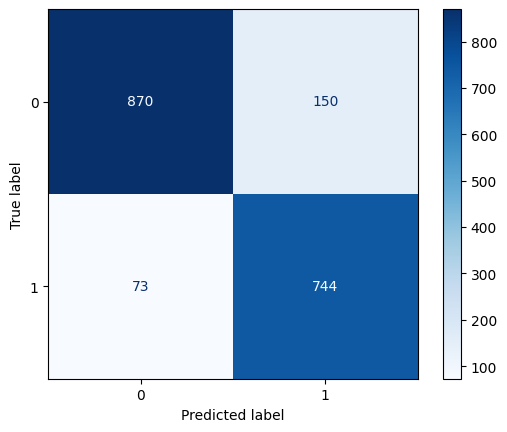

Validation Accuracy: 0.8786064235166031
Validation Loss: 0.2977069024237899


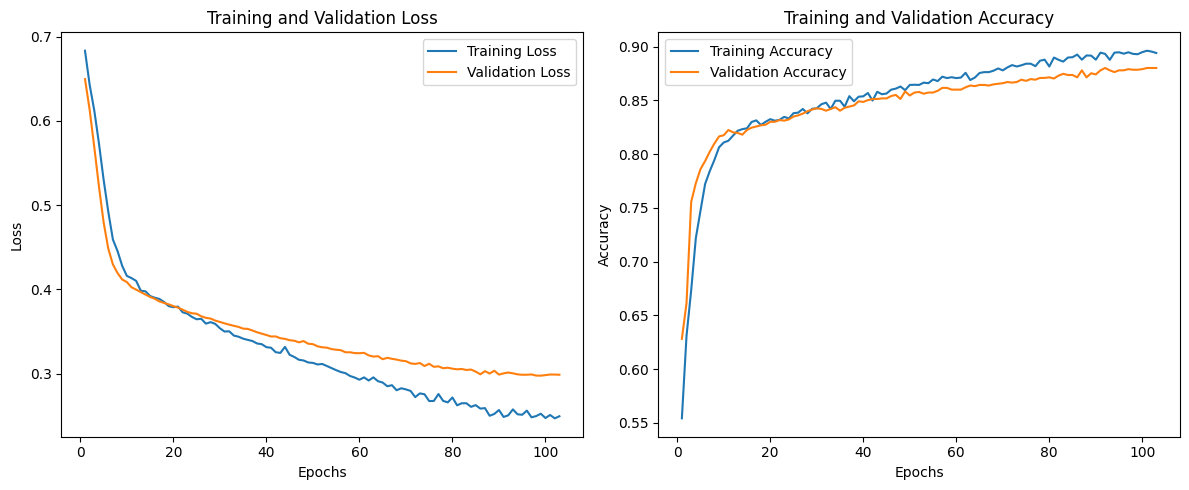

In [ ]:
# Predictions
preds = model.predict(data_valid)

# Convert predictions and true labels to classes
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_valid.values, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Compute accuracy and log loss
accuracy = accuracy_score(y_true, y_pred)
loss = log_loss(y_valid, preds)

print(f'Validation Accuracy: {accuracy}')
print(f'Validation Loss: {loss}')

# Plot training and validation accuracy and loss
epochs = range(1, len(history_all['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history_all['train_loss'], label='Training Loss')
plt.plot(epochs, history_all['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history_all['train_accuracy'], label='Training Accuracy')
plt.plot(epochs, history_all['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Display classification report
print("Classification Report:")
print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1020
           1       0.83      0.91      0.87       817

    accuracy                           0.88      1837
   macro avg       0.88      0.88      0.88      1837
weighted avg       0.88      0.88      0.88      1837

